Solucion de un sistema de segundo orden.  
Sistema masa resorte amortiguador sin entradas

In [60]:
# Modulos
import numpy as np
import matplotlib.pyplot as plt

# Paràmetros del sistema
M = 50
C = 0.3
K = 100

# Condiciones iniciales
x10 = 0.1
x20 = 0

# Discretizaciòn del tiempo
h = 0.1
tsim = 300
t = np.arange(0,tsim+h,h)


# Funcion a resolver
def f(t,x):
    x1 = x[0]
    x2 = x[1]
    f1 = x2
    f2 = -K/M*x1 -C/M*x2
    return [f1,f2]

In [53]:
# Solucion euler
y = np.zeros(len(t))
v = np.zeros(len(t))
y[0] = x10
v[0] = x20
for i in range(len(t)-1):
    f1,f2 = f([y[i],v[i]],t[i])
    y[i+1] = y[i] + h*f1
    v[i+1] = v[i] + h*f2

In [54]:
# solucion con RK4
y_rk = np.zeros(len(t))
v_rk = np.zeros(len(t))
y_rk[0] = x10
v_rk[0] = x20
for i in range(len(t)-1):
    k11, k12 = f([y_rk[i],v_rk[i]],t[i])
    ttemp = t[i]+1/2*h
    x1temp = y_rk[i] + 1/2*h*k11
    x2temp = v_rk[i] + 1/2*h*k12
    k21,k22 = f([x1temp,x2temp],ttemp)
    ttemp = t[i]+1/2*h
    x1temp = y_rk[i] + 1/2*h*k21
    x2temp = v_rk[i] + 1/2*h*k22
    k31,k32 = f([x1temp,x2temp],ttemp)
    ttemp = t[i]+h
    x1temp = y_rk[i] + h*k31
    x2temp = v_rk[i] + h*k32
    k41,k42 = f([x1temp,x2temp],ttemp)
    y_rk[i+1] = y_rk[i] + 1/6*h*(k11+2*k21+2*k31+k41)
    v_rk[i+1] = v_rk[i] + 1/6*h*(k12+2*k22+2*k32+k42)

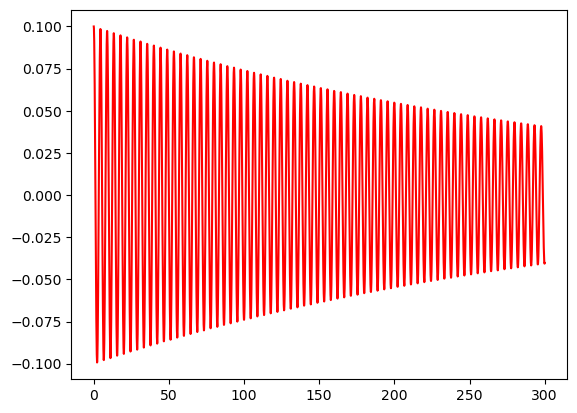

In [55]:
#plt.plot(t,y)
plt.plot(t,y_rk,'r')

In [61]:
from scipy.integrate import solve_ivp

a = solve_ivp(f,[0,tsim],[x10,x20])

In [62]:
a

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  4.950e-03 ...  2.996e+02  3.000e+02]
        y: [[ 1.000e-01  1.000e-01 ... -3.939e-02 -3.887e-02]
            [ 0.000e+00 -9.901e-04 ... -1.299e-02  1.577e-02]]
      sol: None
 t_events: None
 y_events: None
     nfev: 2642
     njev: 0
      nlu: 0